### Data Preprocessing

# **Mini Project 2 - CAPO TCS**
#### **Nik, Sal, and Samia (Team Pineapple)**

In [2]:
# Install the required libraries for Data Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Install the required librabries for Linear Regression
import sklearn.model_selection as model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [212]:
# Install the required libraries for Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [124]:
data = pd.read_csv('capo_data.csv')

data.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___wbc,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral
0,16,43.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,1,0,0,1,1,1,1
1,17,60.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,18,45.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,0,0,0,0,0,0,0,0
3,19,35.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
4,20,61.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [125]:
#data.info()
#We have a bunch of columns that are missing the
#full 8230 rows in the dataset. The day test
#and case id values are all integers, otherwise, all
#other columns are floats. 
print(f'dataset is {data.shape[0]} by {data.shape[1]}')

dataset is 8230 by 100


In [126]:
#data.columns

In [127]:
#Check for null values in the data
#data.isna().sum().sort_values(ascending=False)
#data.isnull().sum()

In [128]:
#Need to .dropna(how = '', axis = 0 for rows and 1 columns)
#and fillna some columns with mode and mean. 

In [129]:
#Dropping columns to leave only 'exam', 'dem', 'cx', and 'test' data per rubric.
data2 = data.drop(['lab_hematocrit', 'lab_hemoglobin', 'lab_bands', 'lab_platelets', 'lab_inr', 'lab_na', 'lab_k', 'lab_bun',
       'lab_creatinine', 'lab_bicarb', 'lab_glucose', 'lab_albumin', 'lab_ast',
       'lab_alt', 'lab_bilirubin', 'lab_trop1', 'lab_trop2', 'lab_trop3',
       'lab_ckmb1', 'lab_ckmb2', 'lab_ckmb3', 'lab_ldl', 'lab_hdl',
       'lab_cholesterol', 'lab_triglycerides', 'lab_lactate', 'lab_hga1c',
       'lab_ldh', 'lab_bnp', 'lab_crp', 'lab_pct', 'lab_vitamind', 'lab_abg',
       'lab_abgph', 'lab_abgpaco2', 'lab_abgpao2', 'lab_abgbicarb',
       'lab_abgfio2'], axis=1)
data2.columns

Index(['case_id', 'dem_age', 'dem_sex', 'dem_pregnant', 'dem_trimester',
       'exam_height', 'exam_weight', 'exam_hr', 'exam_rr', 'exam_sbp',
       'exam_dbp', 'exam_temp', 'exam_o2sat', 'exam_o2satvalue', 'exam_fio2',
       'exam_mental', 'lab_wbc', 'cx_rul', 'cx_rml', 'cx_rll', 'cx_lul',
       'cx_lll', 'cx_db', 'cx_du', 'cx_cav', 'cx_pe', 'day0test___cough',
       'day0test___afebrile', 'day0test___wbc', 'day0test___oral',
       'day1test___cough', 'day1test___afebrile', 'day1test___wbc',
       'day1test___oral', 'day2test___cough', 'day2test___afebrile',
       'day2test___wbc', 'day2test___oral', 'day3test___cough',
       'day3test___afebrile', 'day3test___wbc', 'day3test___oral',
       'day4test___cough', 'day4test___afebrile', 'day4test___wbc',
       'day4test___oral', 'day5test___cough', 'day5test___afebrile',
       'day5test___wbc', 'day5test___oral', 'day6test___cough',
       'day6test___afebrile', 'day6test___wbc', 'day6test___oral',
       'day7test___cough', '

In [130]:
#dropping all rows which sex and exam_mental is null
data2 = data2.dropna(subset=["dem_sex"])
data2 = data2.dropna(subset=["exam_mental"])

In [131]:
# Checking for amount of null values present
pd.set_option('display.max_rows', None)

data2.isnull().sum().sort_values(ascending=False)

dem_trimester              7721
cx_du                      7402
cx_db                      7395
dem_pregnant               6907
exam_fio2                  5951
exam_rr                    4782
exam_height                4765
exam_weight                4681
exam_o2satvalue            4436
exam_dbp                   4265
exam_sbp                   4262
exam_o2sat                 4162
exam_hr                    2779
exam_temp                  2770
lab_wbc                    2765
cx_rul                       35
cx_lul                       31
cx_rml                       29
cx_lll                       28
cx_rll                       28
cx_cav                       16
cx_pe                        11
dem_age                       1
dem_sex                       0
case_id                       0
exam_mental                   0
day0test___cough              0
day0test___afebrile           0
day0test___wbc                0
day0test___oral               0
day1test___cough              0
day1test

In [132]:
#Dropping these three columns due to insufficient quanity. 
data2 = data2.drop(['cx_du', 'cx_db', 'exam_fio2'], axis=1)

In [133]:
#imputing missing values so that all there are no missing values
imputation_dict = {
    'dem_trimester': 0,
    'dem_pregnant': 0,
    'dem_age': data2['dem_age'].mean(),
    'exam_temp': data2['exam_temp'].mean(),
    'exam_hr': data2['exam_hr'].mean(),
    'exam_rr': data2['exam_rr'].mean(),
    'exam_sbp': data2['exam_sbp'].mean(),
    'exam_dbp': data2['exam_dbp'].mean(),
    'exam_o2satvalue': data2['exam_o2satvalue'].mean(),
    'exam_height': data2['exam_height'].mean(),
    'exam_weight': data2['exam_weight'].mean(),
    'lab_wbc': data2['lab_wbc'].mean(),

    'exam_o2sat': data2['exam_o2sat'].mode()[0],
    'cx_rul': data2['cx_rul'].mode()[0],
    'cx_lul': data2['cx_lul'].mode()[0],
    'cx_rml': data2['cx_rml'].mode()[0],
    'cx_rll': data2['cx_rll'].mode()[0],
    'cx_lll': data2['cx_lll'].mode()[0],
    'cx_cav': data2['cx_cav'].mode()[0],
    'cx_pe': data2['cx_pe'].mode()[0],
}
#Imputed the mean for continuous measures, mode for others. 

In [ ]:
# Checking if missing values were imputed
data3 = data2.fillna(value=imputation_dict)
data3.isnull().sum()

case_id                    0
dem_age                    0
dem_sex                    0
dem_pregnant               0
dem_trimester              0
exam_height                0
exam_weight                0
exam_hr                    0
exam_rr                    0
exam_sbp                   0
exam_dbp                   0
exam_temp                  0
exam_o2sat                 0
exam_o2satvalue            0
exam_mental                0
lab_wbc                    0
cx_rul                     0
cx_rml                     0
cx_rll                     0
cx_lul                     0
cx_lll                     0
cx_cav                     0
cx_pe                      0
day0test___cough           0
day0test___afebrile        0
day0test___wbc             0
day0test___oral            0
day1test___cough           0
day1test___afebrile        0
day1test___wbc             0
day1test___oral            0
day2test___cough           0
day2test___afebrile        0
day2test___wbc             0
day2test___ora

In [135]:
#Run this cell to save the changes made.
# data3.to_csv("CAPOEDA.csv", index = False)

In [181]:
data4 = pd.read_csv("CAPOEDA.csv")
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7740 entries, 0 to 7739
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   case_id                  7740 non-null   int64  
 1   dem_age                  7740 non-null   float64
 2   dem_sex                  7740 non-null   float64
 3   dem_pregnant             7740 non-null   float64
 4   dem_trimester            7740 non-null   float64
 5   exam_height              7740 non-null   float64
 6   exam_weight              7740 non-null   float64
 7   exam_hr                  7740 non-null   float64
 8   exam_rr                  7740 non-null   float64
 9   exam_sbp                 7740 non-null   float64
 10  exam_dbp                 7740 non-null   float64
 11  exam_temp                7740 non-null   float64
 12  exam_o2sat               7740 non-null   float64
 13  exam_o2satvalue          7740 non-null   float64
 14  exam_mental             

### Linear Regression Model - Predicting TCS
* Building a Linear Regression Model to to predict the Time to Clinical Stability (TCS) using the demographic, examination, and chest x-ray data 
* The Time to Clinical Stability (TCS) is defined by the first day the patient to achieve clinical stability. 
* This occurs when the patient meets all four criteria where 1 = Yes and 0 = No. If the patient meets all criteria for a given day (1111), the patient has a TSC score equivalent to that given day
* 4 criteria for achieving stability:
    * Improvement in cough/shortness of breath.
    * Temperature of less than 37.8C or 100F.
    * White blood cell counts of 10% or more lower than the previous day.
    * Whether the patient can eat or take pills orally.
* Discrete non-binary target variable: TCS = 1 - 8 

#### Creating Target Variable

In [182]:
# Creating a Target variable for Linear Regression Model

# Logic - Psuedocode:
# For Day 1: If 1111 --> TSC = 1 (Patient's Time to CLinical Stability TCS was achieved on Day 1)
# If not 1111, check if next day is 1111
# For Day 2: If 1111 --> TSC = 2 (Patient's Time to CLinical Stability TCS was achieved on Day 2)
# If not 1111, check if next day is 1111
# For Day 3: If 1111 --> TSC = 3 (Patient's Time to CLinical Stability TCS was achieved on Day 3)
# If not 1111, check if next day is 1111
# For Day 4: If 1111 --> TSC = 4 (Patient's Time to CLinical Stability TCS was achieved on Day 4)
# If not 1111, check if next day is 1111
# For Day 5: If 1111 --> TSC = 5 (Patient's Time to CLinical Stability TCS was achieved on Day 5)
# If not 1111, check if next day is 1111
# For Day 6: If 1111 --> TSC = 6 (Patient's Time to CLinical Stability TCS was achieved on Day 6)
# If not 1111, check if next day is 1111
# For Day 7: If 1111 --> TSC = 7 (Patient's Time to CLinical Stability TCS was achieved on Day 7)
# If not 1111 by Day 7, then TSC = 8 (Patient's Time to CLinical Stability TCS is assumed to be achieved on Day 8)


In [183]:
# creating function to calculate TCS Target variable for each patient if they achieved stabilitity for a given day by achieving 1 for all four criteria
def patient_tcs(row):
    # For day 1 to day 7
    for day in range(1, 8):
        criteria = [
            # criteria for improvement in cough/shortness of breath (Y/N) = (1/0)
            row[f'day{day}test___cough'],
            # criteria for temperature of less than 37.8C or 100F (Y/N) = (1/0)
            row[f'day{day}test___afebrile'],
            # criteria for white blood cell counts of 10% or more lower than the previous day (Y/N) = (1/0)
            row[f'day{day}test___wbc'],
            # criteria for whether the patient can eat or take pills orally (Y/N) = (1/0)
            row[f'day{day}test___oral'] 
        ]

        # Check if all criteria is met (1111) for the given day
        if all(x == 1 for x in criteria):
            return day
    # If patient does not achieve stability by day 7, TSC = 8
    return 8

In [184]:
# create the target column
data4['tcs_day_linear'] = data4.apply(patient_tcs, axis=1)

In [185]:
# viewing the column
data4.loc[3:30,['case_id','tcs_day_linear']]

,case_id,tcs_day_linear
3,19,4
4,20,4
5,21,4
6,22,3
7,23,2
8,24,8
9,28,8
10,29,3
11,30,2
12,31,1


In [186]:
data4.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,4
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,4
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,3
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,2
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,1,1,1,1,8
9,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,1,1,0,0,1,1,1,1,8


<Axes: ylabel='count'>

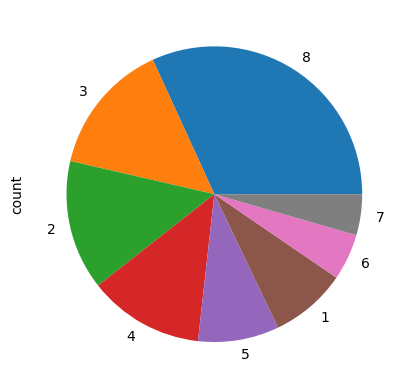

In [187]:
# visualizing the distribution of tcs scores for the data
data4['tcs_day_linear'].value_counts().plot(kind='pie')

In [188]:
data4['tcs_day_linear'].value_counts()

tcs_day_linear
8    2464
3    1127
2    1099
4     978
5     686
1     647
6     393
7     346
Name: count, dtype: int64

In [189]:
# creating copy of dataset to use for linear model
# data4.to_csv("CAPOEDA_LINEAR2.csv", index = False)

# loading data
data5 = pd.read_csv("CAPOEDA_LINEAR2.csv")
data5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7740 entries, 0 to 7739
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   case_id                  7740 non-null   int64  
 1   dem_age                  7740 non-null   float64
 2   dem_sex                  7740 non-null   float64
 3   dem_pregnant             7740 non-null   float64
 4   dem_trimester            7740 non-null   float64
 5   exam_height              7740 non-null   float64
 6   exam_weight              7740 non-null   float64
 7   exam_hr                  7740 non-null   float64
 8   exam_rr                  7740 non-null   float64
 9   exam_sbp                 7740 non-null   float64
 10  exam_dbp                 7740 non-null   float64
 11  exam_temp                7740 non-null   float64
 12  exam_o2sat               7740 non-null   float64
 13  exam_o2satvalue          7740 non-null   float64
 14  exam_mental             

In [190]:
# drop case_id and lab_wbc columns
data5.drop(['case_id', 'lab_wbc'], axis=1, inplace=True)

In [191]:
data5.head(10)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,1,0,0,1,1,1,1,8
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,0,0,0,0,0,0,0,0,5
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,1,1,1,1,1,1,1,4
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,4
5,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,0,0,0,0,0,0,0,0,4
6,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,3
7,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,2
8,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,1,1,1,1,8
9,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,1,1,0,0,1,1,1,1,8


In [192]:
# dropping all columns which are not demographic, exam, or chest x-ray (cx) variables
data5.drop(data5.columns[21:-1], axis=1)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe,tcs_day_linear
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,8
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,4
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7735,78.0,1.0,0.0,0.0,168.000000,58.000000,120.000000,23.761663,128.000000,87.000000,...,100.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,4
7736,61.0,0.0,0.0,0.0,160.829244,73.044786,86.000000,23.761663,126.184301,72.164604,...,96.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
7737,27.0,1.0,0.0,0.0,166.000000,64.000000,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2
7738,36.0,0.0,0.0,0.0,153.000000,72.000000,134.000000,30.000000,126.000000,87.000000,...,84.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8


#### Splitting Data

In [193]:
# selecting explanatory variables (x) - demographic (dem_), exam (exam_) and chest x-ray (cx_) data
X = data5.drop(['tcs_day_linear'], axis=1)

In [194]:
#selecting the tagret variable (y) - tcs score for patients
y = data5['tcs_day_linear']

In [195]:
# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
# setting arbitrary random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

#### Training the Linear Regression Model and Executing

In [196]:
regressor=LinearRegression()

#Train your model
regressor.fit(X_train, y_train)

LinearRegression()

In [197]:
# Predict y values from the test data set and saving them to variable y_pred
y_pred = regressor.predict(X_test.values)

#### Evaluating Linear Regression Model

In [198]:
# Train set
y_train_pred = regressor.predict(X_train)
# calculate the mean squared error of the train set
mse_train = mean_squared_error(y_train, y_train_pred)
# calculate the root mean squared error of the train set
rmse_train = np.sqrt(mse_train)

print("MSE (train):", mse_train)
print("RMSE (train):", rmse_train)

# Test set
y_test_pred = regressor.predict(X_test)
# calculate the mean squared error of the train set
mse_test = mean_squared_error(y_test, y_test_pred)
# calculate the root mean squared error of the train set
rmse_test = np.sqrt(mse_test)

print("MSE (test):", mse_test)
print("RMSE (test):", rmse_test)

MSE (train): 2.3175356479392124
RMSE (train): 1.5223454430382128
MSE (test): 2.3353442015704586
RMSE (test): 1.5281833010376924


Explain results

In [199]:
# Calculate the R-squared value of the model (Test set only)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.6265576693684842


Explain results

In [ ]:
# note to self: refer to notebook MLA2_SZM

### Logistic Regression Model #1 - Stable vs. Not Stable
* Building a logistic regression model to predict whether the patient was stable or not stable using the same columns in the linear regression model
* Stable vs. Not Stable (Binary Target Variable)
* Patient achieved clinical stability within 7 days (TCS = 1 - 7)
    * Stable = 1 
* Patient did not achieve clinical stability within 7 days (TCS = 8) 
    * Not Stable = 0

#### Creating Target Variable

In [206]:
# loading data
data6 = pd.read_csv("CAPOEDA_LINEAR2.csv")
data6.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,4
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4


In [207]:
# creating binary target variable
data6['stable_binary'] = (data6['tcs_day_linear'] <= 7).astype(int)

In [208]:
# cheacking if target variable added
data6.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear,stable_binary
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,1,0,0,1,1,1,1,8,0
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,1,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,5,1
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,4,1
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,4,1
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,4,1
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,3,1
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,2,1
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,1,1,1,1,8,0
9,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,0,0,1,1,1,1,8,0


In [209]:
# drop case_id and lab_wbc columns
data6.drop(['case_id', 'lab_wbc'], axis=1, inplace=True)

In [210]:
data6.head(10)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear,stable_binary
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,1,0,0,1,1,1,1,8,0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,1,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,5,1
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,1,1,1,1,1,1,4,1
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,4,1
5,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,4,1
6,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,3,1
7,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,2,1
8,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,1,1,1,1,8,0
9,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,0,0,1,1,1,1,8,0


In [211]:
# dropping all columns which are not demographic, exam, or chest x-ray (cx) variables
data6.drop(data6.columns[21:-1], axis=1)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe,stable_binary
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7735,78.0,1.0,0.0,0.0,168.000000,58.000000,120.000000,23.761663,128.000000,87.000000,...,100.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
7736,61.0,0.0,0.0,0.0,160.829244,73.044786,86.000000,23.761663,126.184301,72.164604,...,96.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
7737,27.0,1.0,0.0,0.0,166.000000,64.000000,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1
7738,36.0,0.0,0.0,0.0,153.000000,72.000000,134.000000,30.000000,126.000000,87.000000,...,84.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


CHANGE THE WORDING (COPY AND PASTED)
* True Positive (TP) — model correctly predicts the positive class (prediction and actual both are positive).
    * This case people survived and the model correctly predicted
* True Negative (TN) — model correctly predicts the negative class (prediction and actual both are negative).
    * This case the people not survived and the model correctly predicted
* False Positive (FP) — model gives the wrong prediction of the negative class (predicted-positive, actual-negative)
    * Actual not survived- model predict survived
* False Negative (FN) — model wrongly predicts the positive class (predicted-negative, actual-positive). 
    * Actual survived - model predict not survived